<a href="https://colab.research.google.com/github/mickaymouse/AppDev-Bitalac/blob/main/Data_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip install pydicom scikit-image pylibjpeg pylibjpeg-libjpeg python-gdcm

import pydicom
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
import pandas as pd
from tqdm.notebook import tqdm

### 1. Load DICOM Image

First, we'll load a sample DICOM image. You'll need to specify the path to your DICOM file. For demonstration, I'll use a placeholder. Replace `dicom_file_path` with the actual path to your DICOM image.

In [3]:
dicom_file_path = '/content/drive/MyDrive/EmoryDatasetKnee/RawDICOMData'
output_file_path = '/content/drive/MyDrive/EmoryDatasetKnee/PreProcessedData'

In [39]:
import pydicom
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# Helper function to safely extract a single numeric value from a DICOM tag
def get_single_numeric_value(ds, tag_name, default=None):
    if tag_name in ds:
        raw_value = ds[tag_name].value
        # Ensure raw_value is iterable if it's a MultiValue or similar, otherwise wrap single value in a list
        if isinstance(raw_value, pydicom.multival.MultiValue):
            value_list = list(raw_value)
        elif isinstance(raw_value, (list, tuple)):
            value_list = raw_value
        else:
            value_list = [raw_value] # Wrap single value in a list

        if value_list: # If list is not empty
            try:
                # Try converting the first element to float
                return float(value_list[0])
            except (ValueError, TypeError):
                pass # Conversion failed, return default
    return default

# Function to preprocess a single DICOM image
def preprocess_dicom_image(dicom_filepath, output_dir, target_size=(512, 512), preview_image=False):
    try:
        ds = pydicom.dcmread(dicom_filepath)
        image = ds.pixel_array

        # 1. Windowing and Photometric Correction
        # Ensure RescaleIntercept and RescaleSlope are float
        if 'RescaleIntercept' in ds and 'RescaleSlope' in ds:
            intercept = get_single_numeric_value(ds, 'RescaleIntercept', 0.0)
            slope = get_single_numeric_value(ds, 'RescaleSlope', 1.0)
            image_rescaled = image * slope + intercept
        else:
            image_rescaled = image

        # Safely get WindowCenter and WindowWidth
        window_center = get_single_numeric_value(ds, 'WindowCenter')
        window_width = get_single_numeric_value(ds, 'WindowWidth')

        if window_center is not None and window_width is not None:
            lower_bound = window_center - window_width / 2
            upper_bound = window_center + window_width / 2
        else:
            # Fallback to min/max if windowing params are missing or invalid
            lower_bound = np.min(image_rescaled)
            upper_bound = np.max(image_rescaled)

        # Check for division by zero in windowing calculation
        denominator = float(upper_bound - lower_bound) # Ensure float division
        if denominator == 0.0:
            # If the range is zero, set image to a neutral gray or black to avoid division by zero
            windowed_image = np.full(image_rescaled.shape, 128, dtype=np.uint8)
        else:
            windowed_image = np.clip(image_rescaled, lower_bound, upper_bound)
            windowed_image = ((windowed_image - lower_bound) / denominator) * 255
            windowed_image = windowed_image.astype(np.uint8)

        if 'PhotometricInterpretation' in ds and ds.PhotometricInterpretation == 'MONOCHROME1':
            windowed_image = 255 - windowed_image

        # 2. Image Normalization: Resize and Intensity Scaling
        resized_image = cv2.resize(windowed_image, target_size, interpolation=cv2.INTER_CUBIC)
        normalized_image = resized_image.astype(np.float32) / 255.0

        # 3. Image Enhancement: CLAHE, and Intensity Normalization (Sharpening removed)
        image_for_enhancement = (normalized_image * 255).astype(np.uint8)

        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        clahe_image = clahe.apply(image_for_enhancement)

        # Sharpening has been removed as per user request
        final_enhanced_image = cv2.normalize(clahe_image, None, 0, 255, cv2.NORM_MINMAX)

        if preview_image:
            plt.figure(figsize=(6, 6))
            plt.imshow(final_enhanced_image, cmap='gray')
            plt.title(f"Preview of {os.path.basename(dicom_filepath)}")
            plt.axis('off')
            plt.show()
            plt.close()

        # Save as PNG
        original_filename = os.path.basename(dicom_filepath)
        output_filename = original_filename.replace('.dcm', '.png')
        output_png_path = os.path.join(output_dir, output_filename)
        cv2.imwrite(output_png_path, final_enhanced_image)

        # Extract basic metadata
        metadata = {
            'filename': original_filename,
            'Rows': ds.Rows,
            'Columns': ds.Columns,
            'PixelSpacing': getattr(ds, 'PixelSpacing', 'N/A'),
            'PhotometricInterpretation': getattr(ds, 'PhotometricInterpretation', 'N/A'),
            'RescaleIntercept': getattr(ds, 'RescaleIntercept', 'N/A'),
            'RescaleSlope': getattr(ds, 'RescaleSlope', 'N/A'),
            'ProcessedPNG_Path': output_png_path
        }
        return metadata

    except Exception as e:
        print(f"Error processing {dicom_filepath}: {e}")
        return None

Previewing: /content/drive/MyDrive/EmoryDatasetKnee/RawDICOMData/KNEE_XRAY_11.dcm


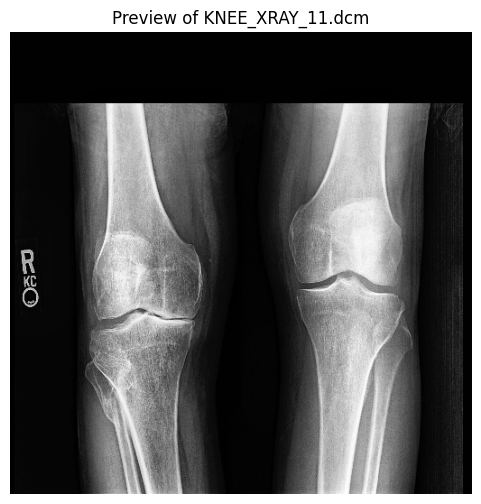

In [40]:
# Get a sample DICOM file for preview
import os

# Ensure dicom_file_path is defined (from previous cells)
if 'dicom_file_path' not in locals() or not os.path.exists(dicom_file_path):
    print("Error: 'dicom_file_path' is not defined or does not exist. Please run previous cells.")
else:
    sample_dicom_files = [f for f in os.listdir(dicom_file_path) if f.endswith('.dcm')]
    if sample_dicom_files:
        first_dicom_file = os.path.join(dicom_file_path, sample_dicom_files[10])
        print(f"Previewing: {first_dicom_file}")
        preprocess_dicom_image(first_dicom_file, output_file_path, preview_image=True)
    else:
        print(f"No DICOM files found in {dicom_file_path} for preview.")

In [41]:
os.makedirs(output_file_path, exist_ok=True)

all_metadata_records = []
processed_count = 0
failed_count = 0

dicom_files = [f for f in os.listdir(dicom_file_path) if f.endswith('.dcm')]

print(f"Found {len(dicom_files)} DICOM files in {dicom_file_path}")
print(f"Saving preprocessed images to {output_file_path}")

for filename in tqdm(dicom_files, desc="Processing DICOM files"):
    full_dicom_path = os.path.join(dicom_file_path, filename)
    metadata = preprocess_dicom_image(full_dicom_path, output_file_path)

    if metadata:
        all_metadata_records.append(metadata)
        processed_count += 1
    else:
        failed_count += 1

print(f"\nBatch processing complete.")
print(f"Successfully processed: {processed_count} files")
print(f"Failed to process: {failed_count} files")

# Save metadata to CSV
if all_metadata_records:
    metadata_df = pd.DataFrame(all_metadata_records)
    metadata_csv_path = os.path.join(output_file_path, 'dicom_metadata.csv')
    metadata_df.to_csv(metadata_csv_path, index=False)
    print(f"Metadata saved to {metadata_csv_path}")
    display(metadata_df.head())
else:
    print("No metadata records to save.")

Found 50 DICOM files in /content/drive/MyDrive/EmoryDatasetKnee/RawDICOMData
Saving preprocessed images to /content/drive/MyDrive/EmoryDatasetKnee/PreProcessedData


Processing DICOM files:   0%|          | 0/50 [00:00<?, ?it/s]


Batch processing complete.
Successfully processed: 50 files
Failed to process: 0 files
Metadata saved to /content/drive/MyDrive/EmoryDatasetKnee/PreProcessedData/dicom_metadata.csv


,filename,Rows,Columns,PixelSpacing,PhotometricInterpretation,RescaleIntercept,RescaleSlope,ProcessedPNG_Path
0,KNEE_XRAY_1.dcm,2517,3028,"[0.139, 0.139]",MONOCHROME2,0.0,1.0,/content/drive/MyDrive/EmoryDatasetKnee/PrePro...
1,KNEE_XRAY_2.dcm,3610,4400,"[0.097, 0.097]",MONOCHROME2,0.0,1.0,/content/drive/MyDrive/EmoryDatasetKnee/PrePro...
2,KNEE_XRAY_4.dcm,1760,2140,"[0.20, 0.20]",MONOCHROME1,N/A,N/A,/content/drive/MyDrive/EmoryDatasetKnee/PrePro...
3,KNEE_XRAY_5.dcm,2539,2438,"[0.139, 0.139]",MONOCHROME2,0.0,1.0,/content/drive/MyDrive/EmoryDatasetKnee/PrePro...
4,KNEE_XRAY_3.dcm,2892,2539,"[0.139, 0.139]",MONOCHROME2,0.0,1.0,/content/drive/MyDrive/EmoryDatasetKnee/PrePro...
